## **association.py**

This is where the pipeline stops listing objects and starts building
relationships.

Detection gives us five riders and four motorcycles. Nothing in that output
says rider 7 is on motorcycle 12. But a helmet violation is a statement about
a *rider on a motorcycle* get the pairing wrong and you attribute the violation to the wrong person, which is worse than missing it entirely.

Three matches happen here, all using the same machinery:

- riders → motorcycles
- helmets / no-helmets → riders
- license plates → motorcycles

This is also the file where a design decision was reversed after the original
approach turned out to fail on real footage. We'll look at both versions and
the evidence for the switch.

## **Setup**

In [1]:
!git clone -q https://github.com/shreyamali17/helmet-violation-detection.git
%cd helmet-violation-detection/project/pipeline
!pip install -q ultralytics scipy

/content/helmet-violation-detection/project/pipeline
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.5 MB/s eta 0:00:00


In [2]:
import numpy as np

#              bike A  bike B  bike C
costs = np.array([
    [  1,      2,      99  ],   # rider 1
    [  2,      99,     99  ],   # rider 2
    [  99,     99,     3   ],   # rider 3
])

# greedy: repeatedly take the lowest remaining cost
taken_rows, taken_cols, greedy_total = set(), set(), 0
work = costs.astype(float).copy()

for _ in range(3):
    i, j = np.unravel_index(np.argmin(work), work.shape)
    greedy_total += costs[i, j]
    print(f"greedy picks rider {i+1} -> bike {'ABC'[j]}  (cost {costs[i, j]})")
    work[i, :] = np.inf
    work[:, j] = np.inf

print(f"\ngreedy total: {greedy_total}")

greedy picks rider 1 -> bike A  (cost 1)
greedy picks rider 3 -> bike C  (cost 3)
greedy picks rider 2 -> bike B  (cost 99)

greedy total: 103


Greedy grabs rider 1 → bike A first, because 1 is the smallest number on the
table. That leaves rider 2 with nothing but a cost of 99.

But rider 1 → bike B costs only 2, and would free bike A for rider 2. Total
cost 2 + 2 + 3 = 7 instead of 1 + 99 + 3 = 103.

The locally best choice blocked the globally best arrangement. That's the
failure mode greedy always has, and in a crowded traffic frame it happens
regularly.

## **The Hungarian Algorithm**

`scipy.optimize.linear_sum_assignment` solves this properly: it finds the set
of pairings with the lowest **total** cost across everyone at once, rather than
committing one pair at a time.

Same table, correct answer.

In [3]:
from scipy.optimize import linear_sum_assignment

row_ind, col_ind = linear_sum_assignment(costs)

total = 0
for r, c in zip(row_ind, col_ind):
    print(f"rider {r+1} -> bike {'ABC'[c]}  (cost {costs[r, c]})")
    total += costs[r, c]

print(f"\noptimal total: {total}")

rider 1 -> bike B  (cost 2)
rider 2 -> bike A  (cost 2)
rider 3 -> bike C  (cost 3)

optimal total: 7


It returns two arrays of indices: `row_ind[k]` is paired with `col_ind[k]`.

Every function in this file follows the same three steps:

1. Build a **cost matrix** one number per possible pairing, answering "how
   bad would this pairing be?"
2. Hand it to `linear_sum_assignment` for the globally optimal set.
3. **Throw out pairings that are still too expensive.**

Step 3 is the one people skip, and it's essential. Read on.

## **The Three-Step Pattern**

Every function in this module follows the same three steps:

1. **Build a cost matrix.** One number per possible pairing, answering the
   question "how poor would this pairing be?"
2. **Solve it.** Hand the matrix to `linear_sum_assignment` to obtain the
   globally optimal set of pairings.
3. **Discard pairings that remain too expensive (> threshold).**

In step three, the threshold is applied **after** the assignment, not before. 
The algorithm is asked for the best arrangement available, and only afterwards is each individual pairing
examined to determine whether it is genuinely acceptable. A "best available"
match is not the same thing as a "good" match. If only one motorcycle appears
in a frame and it is nowhere near the rider, it remains the best option and
still requires rejection.

## **Two Definitions of Cost**

For rider-to-motorcycle matching the module contains two definitions. Both
produce a matrix of the same shape, but they disagree about what "close" means.

| Method | Cost formula | Units | Default threshold (`config.py`) |
|---|---|---|---|
| `xdist` | Horizontal distance between box centres | Pixels | 300 |
| `iou` | `1 - IoU` between the two boxes | 0 to 1 | 0.9 |

We use this formula because minimizing cost helps the system find the best rider-motorcycle pairs. It focuses on two main rules:

* **Distance:** The smaller the distance between a rider and a motorcycle on the screen, the better the match.
Cost matrix is calculated as: `cost[i][j] = |x_center(rider[i]) - x_center(moto[j])|`
* **Overlap (IoU):** A good match means their boxes overlap a lot (high IoU). Since our goal is to *minimize* the final cost number, we use $1 - \text{IoU}$. This ensures that more overlap directly results in a lower cost. Cost matrix is calculated as: 
`cost[i][j] = 1 - iou(rider[i], moto[j])`

In [4]:
import numpy as np
from geometry import x_center, iou


def build_cost_matrix_xdist(riders, motorcycles):
    """ORIGINAL method: cost = horizontal pixel distance between box centers."""
    rider_ids = list(riders.keys())
    moto_ids = list(motorcycles.keys())
    cost_matrix = np.zeros((len(rider_ids), len(moto_ids)))
    for i, rid in enumerate(rider_ids):
        rx = x_center(riders[rid])
        for j, mid in enumerate(moto_ids):
            cost_matrix[i, j] = abs(rx - x_center(motorcycles[mid]))
    return cost_matrix, rider_ids, moto_ids


def build_cost_matrix_iou(riders, motorcycles):
    """NEW method: cost = 1 - IoU between rider and motorcycle boxes."""
    rider_ids = list(riders.keys())
    moto_ids = list(motorcycles.keys())
    cost_matrix = np.zeros((len(rider_ids), len(moto_ids)))
    for i, rid in enumerate(rider_ids):
        for j, mid in enumerate(moto_ids):
            cost_matrix[i, j] = 1.0 - iou(riders[rid], motorcycles[mid])
    return cost_matrix, rider_ids, moto_ids

Note the units are completely different. `xdist` produces pixel distances
tens or hundreds. `iou` produces `1 : overlap`, always between 0 and 1.

That's why each method carries its own threshold:

```python
DEFAULT_MAX_COST = {
    "xdist": 300,    # pixels
    "iou": 0.9,      # means IoU >= 0.1
}
```

A threshold tuned for one is meaningless for the other.

## **Function**

Note where the threshold is applied: **after** the assignment, not before.

The algorithm is asked for the best arrangement available, and only then do we
check whether each individual pairing is actually good enough to keep. A "best
available" match is not the same thing as a "good" match if there's only one
motorcycle in frame and it's nowhere near the rider, it's still the best
option, and it still needs rejecting.

In [5]:
from scipy.optimize import linear_sum_assignment

DEFAULT_MAX_COST = {
    "xdist": 300,
    "iou": 0.9,
}


def associate_riders_to_motorcycles(riders, motorcycles, method="iou", max_cost=None):
    max_cost = max_cost if max_cost is not None else DEFAULT_MAX_COST[method]
    if not riders or not motorcycles:
        return []

    if method == "xdist":
        cost_matrix, rider_ids, moto_ids = build_cost_matrix_xdist(riders, motorcycles)
    elif method == "iou":
        cost_matrix, rider_ids, moto_ids = build_cost_matrix_iou(riders, motorcycles)
    else:
        raise ValueError(f"Unknown method: {method}")

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return [(rider_ids[r], moto_ids[c])
            for r, c in zip(row_ind, col_ind)
            if cost_matrix[r, c] <= max_cost]

The `if not riders or not motorcycles` guard matters more than it looks.
`linear_sum_assignment` raises on an empty matrix, and frames with no riders
are entirely normal. Returning an empty list keeps the pipeline moving.

## **Trying both on a real frame**

Let's find a frame where the two methods disagree.

In [6]:
from ultralytics import YOLO
import config
from detection import get_frame_detections

model = YOLO(config.MODEL_PATH)

results = model.track(
    source=config.VIDEO_PATH,
    classes=list(config.CLASS_NAMES.keys()),
    tracker=config.TRACKER,
    persist=True, stream=True, verbose=False,
)

TARGET_FRAME = 220

for i, r in enumerate(results):
    if i == TARGET_FRAME:
        det, confs = get_frame_detections(r)
        frame_img = r.orig_img
        break

riders = det["rider"]
motorcycles = det["motorcycle"]

print(f"frame {TARGET_FRAME}: {len(riders)} riders, {len(motorcycles)} motorcycles")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 288ms
Prepared 1 package in 84ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

frame 220: 4 riders, 3 motorcycles


Look at the two cost matrices side by side before running the assignment.

In [7]:
cm_x, rids, mids = build_cost_matrix_xdist(riders, motorcycles)
cm_i, _, _ = build_cost_matrix_iou(riders, motorcycles)

print("xdist cost (pixels, lower = better):")
print("        " + "".join(f"M{m:<8}" for m in mids))
for i, rid in enumerate(rids):
    print(f"  R{rid:<5}" + "".join(f"{v:<9.0f}" for v in cm_x[i]))

print("\niou cost (1 - overlap, lower = better):")
print("        " + "".join(f"M{m:<8}" for m in mids))
for i, rid in enumerate(rids):
    print(f"  R{rid:<5}" + "".join(f"{v:<9.3f}" for v in cm_i[i]))

xdist cost (pixels, lower = better):
        M5       M14      M1241    
  R7    4        20       247      
  R1174 146      170      396      
  R1183 250      226      1        
  R1295 280      256      30       

iou cost (1 - overlap, lower = better):
        M5       M14      M1241    
  R7    0.438    0.803    1.000    
  R1174 1.000    1.000    1.000    
  R1183 1.000    1.000    0.497    
  R1295 1.000    1.000    1.000    


Rows of `1.000` in the second table mean zero overlap : that rider's box
doesn't touch that motorcycle's box at all. The first table has no way to
express that; every cell is just some number of pixels.

In [8]:
xdist_pairs = dict(associate_riders_to_motorcycles(riders, motorcycles, method="xdist"))
iou_pairs   = dict(associate_riders_to_motorcycles(riders, motorcycles, method="iou"))

print(f"xdist: {len(xdist_pairs)} pairings")
for rid, mid in xdist_pairs.items():
    print(f"  rider {rid} -> motorcycle {mid}   (actual overlap: {iou(riders[rid], motorcycles[mid]):.3f})")

print(f"\niou:   {len(iou_pairs)} pairings")
for rid, mid in iou_pairs.items():
    print(f"  rider {rid} -> motorcycle {mid}   (actual overlap: {iou(riders[rid], motorcycles[mid]):.3f})")

xdist: 3 pairings
  rider 7 -> motorcycle 14   (actual overlap: 0.197)
  rider 1174 -> motorcycle 5   (actual overlap: 0.000)
  rider 1183 -> motorcycle 1241   (actual overlap: 0.503)

iou:   2 pairings
  rider 7 -> motorcycle 5   (actual overlap: 0.562)
  rider 1183 -> motorcycle 1241   (actual overlap: 0.503)


## **Seeing It**

Lines drawn between paired objects.

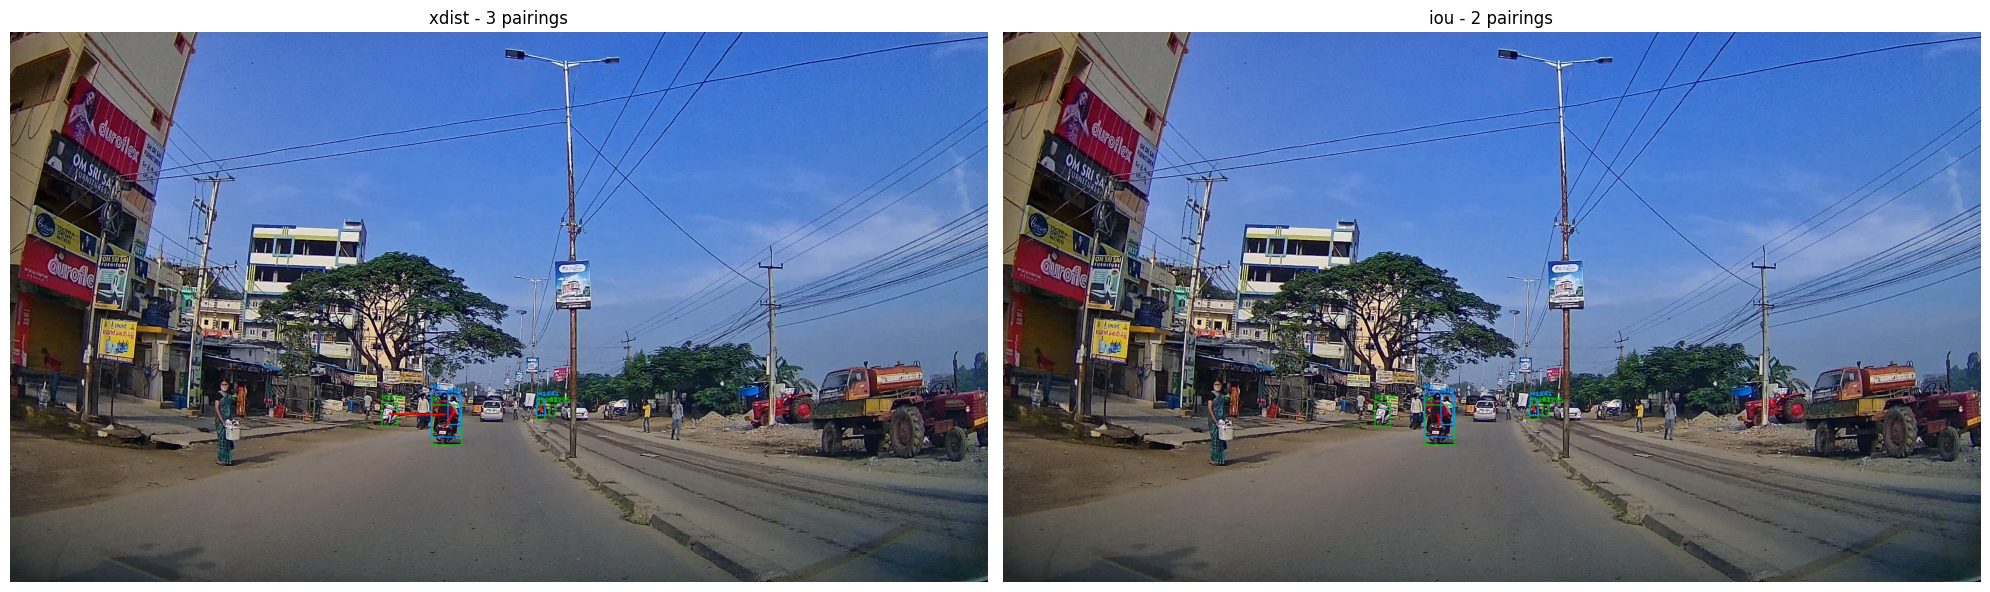

In [9]:
import cv2
import matplotlib.pyplot as plt


def draw_pairings(img, riders, motorcycles, pairs):
    img = img.copy()
    for rid, box in riders.items():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(img, f"R{rid}", (x1, max(y1-8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)
    for mid, box in motorcycles.items():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 150, 0), 2)
        cv2.putText(img, f"M{mid}", (x1, max(y1-8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 150, 0), 2)
    for rid, mid in pairs.items():
        rx1, ry1, rx2, ry2 = map(int, riders[rid])
        mx1, my1, mx2, my2 = map(int, motorcycles[mid])
        cv2.line(img, ((rx1+rx2)//2, (ry1+ry2)//2),
                      ((mx1+mx2)//2, (my1+my2)//2), (0, 0, 255), 3)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(draw_pairings(frame_img, riders, motorcycles, xdist_pairs))
axes[0].set_title(f"xdist - {len(xdist_pairs)} pairings")
axes[0].axis("off")
axes[1].imshow(draw_pairings(frame_img, riders, motorcycles, iou_pairs))
axes[1].set_title(f"iou - {len(iou_pairs)} pairings")
axes[1].axis("off")
plt.tight_layout()
plt.show()

The xdist panel draws more lines, and some of them connect riders to
motorcycles they have no contact with chosen because their horizontal
positions happened to line up. With a 300-pixel threshold, quite a lot of the
frame qualifies as "close."

The iou panel draws fewer lines, and leaves some riders unpaired. Every line
it does draw corresponds to real box overlap.

For this system that trade is clearly worth it. A wrong pairing can attribute
a violation to the wrong rider. A missing pairing just means that rider isn't
checked *this frame* and matching runs again on the next one, and the one
after that.

`x_center` stays in `geometry.py` only to make this comparison possible. The
pipeline default is `iou`.

## **Matching Heads to Riders**

Same machinery, different cost and one design decision worth noticing.

Helmets and no-helmets arrive as two separate detection classes. This function
merges them into a single pool of "heads" before matching, tagging each one
with which type it was.

In [10]:
from geometry import top_center, center
from config import HEAD_RIDER_MAX_COST


def associate_heads_to_riders(riders, helmets, no_helmets,
                              helmet_confs=None, no_helmet_confs=None,
                              max_cost=None):
    """Returns {rider_id: (status, model_confidence)}."""
    max_cost = max_cost if max_cost is not None else HEAD_RIDER_MAX_COST
    helmet_confs = helmet_confs or {}
    no_helmet_confs = no_helmet_confs or {}

    # merge both classes into one pool, remembering which was which
    heads, head_type, head_conf = {}, {}, {}
    for hid, box in helmets.items():
        heads[hid] = box; head_type[hid] = "helmet"; head_conf[hid] = helmet_confs.get(hid)
    for hid, box in no_helmets.items():
        heads[hid] = box; head_type[hid] = "no_helmet"; head_conf[hid] = no_helmet_confs.get(hid)

    if not riders or not heads:
        return {}

    rider_ids, head_ids = list(riders.keys()), list(heads.keys())
    cost_matrix = np.zeros((len(rider_ids), len(head_ids)))
    for i, rid in enumerate(rider_ids):
        rx, ry = top_center(riders[rid])          # head sits at the TOP of a rider
        for j, hid in enumerate(head_ids):
            hx, hy = center(heads[hid])
            cost_matrix[i, j] = ((rx-hx)**2 + (ry-hy)**2) ** 0.5

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return {
        rider_ids[r]: (head_type[head_ids[c]], head_conf[head_ids[c]])
        for r, c in zip(row_ind, col_ind) if cost_matrix[r, c] <= max_cost
    }

## **Why merge the two classes**

Because a rider has exactly one head.

If helmets and no-helmets were matched separately, the same rider could come
back paired with a helmet *and* a no-helmet two contradictory answers, and
nothing to arbitrate between them.

Merging first makes the two classes compete for the same rider through the
same assignment. Whichever detection is geometrically closest wins, and each
rider gets at most one verdict. The constraint is enforced by the structure
rather than by a cleanup step afterwards.

Note the cost here is plain Euclidean distance from the rider's **top edge**
to the head's center : the `top_center` choice from `geometry.py`, doing real
work.

In [11]:
head_matches = associate_heads_to_riders(
    riders, det["helmet"], det["no_helmet"],
    helmet_confs=confs["helmet"], no_helmet_confs=confs["no_helmet"],
)

for rider_id, (status, model_conf) in head_matches.items():
    conf_str = f"{model_conf:.2f}" if model_conf is not None else "n/a"
    print(f"rider {rider_id:<6} {status:<10} (model confidence {conf_str})")

rider 7      no_helmet  (model confidence 0.40)


Two different confidences appear in this pipeline and it's worth keeping them
apart.

**Model confidence** is what comes back here how sure YOLO was about *this
one detection in this one frame*.

**Temporal confidence**, computed in the next stage, is how consistently a
rider's status held up across many frames.

A single detection at 0.95 is not the same as twenty detections that agree.
The second is what actually earns a violation.

## **Matching plates to motorcycles**

The third match, and the simplest. Identical structure to heads-to-riders,
with `bottom_center` instead of `top_center` plates are mounted low on a
bike.

In [12]:
from geometry import bottom_center
from config import PLATE_MOTO_MAX_COST


def associate_plates_to_motorcycles(motorcycles, plates, max_cost=None):
    max_cost = max_cost if max_cost is not None else PLATE_MOTO_MAX_COST
    if not motorcycles or not plates:
        return {}
    moto_ids, plate_ids = list(motorcycles.keys()), list(plates.keys())
    cost_matrix = np.zeros((len(moto_ids), len(plate_ids)))
    for i, mid in enumerate(moto_ids):
        mx, my = bottom_center(motorcycles[mid])
        for j, pid in enumerate(plate_ids):
            px, py = center(plates[pid])
            cost_matrix[i, j] = ((mx-px)**2 + (my-py)**2) ** 0.5
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    return {moto_ids[r]: plate_ids[c]
            for r, c in zip(row_ind, col_ind) if cost_matrix[r, c] <= max_cost}

In [13]:
plate_matches = associate_plates_to_motorcycles(motorcycles, det["license_plate"])

print(f"{len(det['license_plate'])} plates detected, {len(plate_matches)} matched to a motorcycle")
for mid, pid in plate_matches.items():
    print(f"  motorcycle {mid} -> plate {pid}")

1 plates detected, 1 matched to a motorcycle
  motorcycle 5 -> plate 832


The threshold here is 100 pixels, more generous than the 60 used for heads.
Plates are small and often partly obscured, so their detected centers wander
more than a head's does.

## **Try it**

**Loosen the overlap requirement.** `max_cost=1.0` accepts any pairing,
including zero overlap:

```python
associate_riders_to_motorcycles(riders, motorcycles, method="iou", max_cost=1.0)
```

How many extra pairings appear, and do they survive a look at the frame?

**Tighten it.** `max_cost=0.5` demands 50% overlap. How many real pairings get
thrown away?

**Change the xdist threshold.** The default is 300 pixels on a 2560-wide frame
more than a tenth of the image. Try 100 and see whether xdist starts
behaving more like iou.

**Find a disagreement.** Loop over frames and print those where the two
methods return different numbers of pairings. How common is it?

## Next

Every match here happens within a single frame, and is recomputed from scratch
on the next one. Nothing yet remembers that rider 7 was paired with motorcycle
12 a moment ago, or that they looked helmetless three frames running.

That memory is what `rm_instance.py` and `temporal.py` add.